In [1]:
import os
import pandas as pd
import datetime as dt
import time
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns
from catboost import CatBoostClassifier

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import roc_auc_score, accuracy_score, ConfusionMatrixDisplay


# Phase 0 - Constants and Functions

In [2]:
# Standardize the 'random_state' parameter across entire project
RND = 42

# Standardize which Scaler to use across the entire project
scaler = StandardScaler()

In [3]:
# function to determine if csv file path exists locally or not
def self_detect(dataset):
    """
    Used to self-detect the path of the dataset.csv file
    """

    tripleten_path = '/datasets/final_provider/'

    local_path = '/Users/georgeknight/Desktop/TripleTen_Projects/Sprint 17 - Final Project/datasets/final_provider'

    # check if the path exists, if not, use the local path
    if os.path.exists(tripleten_path):
        dataset_path = os.path.join(tripleten_path, dataset)
    else:
        dataset_path = os.path.join(local_path, dataset)

    return dataset_path

In [4]:
# function to loop over all categorical columns and calculate the churn rate
def churn_rate_by_category(df, column):
    """
    Calculates the churn rate based on a dataframe and a given column name.
    """

    summary = df_final.groupby(column)['Churned'].agg(['sum', 'count'])
    summary['churn_rate'] = round(summary['sum'] / summary['count'], 4)

    return summary

# Phase 1 - Load, Merge, Consolidate

### Step 1.1 - Load Datasets into DataFrames

In [5]:
# loading all 4 datasets using 'self_detect' function
df_contract = pd.read_csv(self_detect('contract.csv'))
df_personal = pd.read_csv(self_detect('personal.csv'))
df_internet = pd.read_csv(self_detect('internet.csv'))
df_phone = pd.read_csv(self_detect('phone.csv'))

In [6]:
df_contract.info()
df_personal.info()
df_internet.info()
df_phone.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   BeginDate         7043 non-null   object 
 2   EndDate           7043 non-null   object 
 3   Type              7043 non-null   object 
 4   PaperlessBilling  7043 non-null   object 
 5   PaymentMethod     7043 non-null   object 
 6   MonthlyCharges    7043 non-null   float64
 7   TotalCharges      7043 non-null   object 
dtypes: float64(1), object(7)
memory usage: 440.3+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   customerID     7043 non-null   object
 1   gender         7043 non-null   object
 2   SeniorCitizen  7043 non-null   int64 
 3   Partner        7043 non-null   object
 4   D

### Step 1.2 - Merge 'df_contract' and 'df_personal'

In [7]:
df_merged = df_contract.merge(df_personal, how='inner', on='customerID')

df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   BeginDate         7043 non-null   object 
 2   EndDate           7043 non-null   object 
 3   Type              7043 non-null   object 
 4   PaperlessBilling  7043 non-null   object 
 5   PaymentMethod     7043 non-null   object 
 6   MonthlyCharges    7043 non-null   float64
 7   TotalCharges      7043 non-null   object 
 8   gender            7043 non-null   object 
 9   SeniorCitizen     7043 non-null   int64  
 10  Partner           7043 non-null   object 
 11  Dependents        7043 non-null   object 
dtypes: float64(1), int64(1), object(10)
memory usage: 660.4+ KB


### Step 1.3 - Left join 'df_internet' and 'df_phone' -- filling missing rows explicitly with "NO Service"

In [8]:
df_second_merge = df_merged.merge(df_internet, how='left', on='customerID')
df_final_merge = df_second_merge.merge(df_phone, how='left', on='customerID')

# fill missing rows from 'df_internet' and 'df_phone' with "No Service"
df_final = df_final_merge.fillna('No Service')

# Verify dtypes and rows match with no missing values
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   BeginDate         7043 non-null   object 
 2   EndDate           7043 non-null   object 
 3   Type              7043 non-null   object 
 4   PaperlessBilling  7043 non-null   object 
 5   PaymentMethod     7043 non-null   object 
 6   MonthlyCharges    7043 non-null   float64
 7   TotalCharges      7043 non-null   object 
 8   gender            7043 non-null   object 
 9   SeniorCitizen     7043 non-null   int64  
 10  Partner           7043 non-null   object 
 11  Dependents        7043 non-null   object 
 12  InternetService   7043 non-null   object 
 13  OnlineSecurity    7043 non-null   object 
 14  OnlineBackup      7043 non-null   object 
 15  DeviceProtection  7043 non-null   object 
 16  TechSupport       7043 non-null   object 


In [9]:
# filter 'TotalCharges' to only rows with blanks
filtered_df = df_final.loc[df_final['TotalCharges'] == ' ']
filtered_df['BeginDate'].unique()

# Resolve the 'TotalCharges' conversion from string to numeric
df_final['TotalCharges'] = pd.to_numeric(df_final['TotalCharges'], errors='coerce').fillna(0.00)
df_final.info()
#df_final['TotalCharges'].isna().sum()
print(df_final.head(10))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   BeginDate         7043 non-null   object 
 2   EndDate           7043 non-null   object 
 3   Type              7043 non-null   object 
 4   PaperlessBilling  7043 non-null   object 
 5   PaymentMethod     7043 non-null   object 
 6   MonthlyCharges    7043 non-null   float64
 7   TotalCharges      7043 non-null   float64
 8   gender            7043 non-null   object 
 9   SeniorCitizen     7043 non-null   int64  
 10  Partner           7043 non-null   object 
 11  Dependents        7043 non-null   object 
 12  InternetService   7043 non-null   object 
 13  OnlineSecurity    7043 non-null   object 
 14  OnlineBackup      7043 non-null   object 
 15  DeviceProtection  7043 non-null   object 
 16  TechSupport       7043 non-null   object 


In [10]:
# Convert 'BeginDate' to dateime
df_final['BeginDate'] = pd.to_datetime(df_final['BeginDate'], errors='coerce', yearfirst=True, format='%Y-%m-%d')

# Create New 'EndDate' column and convert for calculation purposes only - preserves the original data
df_final['EndDate_dt'] = pd.to_datetime(df_final['EndDate'], errors='coerce', yearfirst=True, format='%Y-%m-%d %H:%M:%S')
df_final['EndDate_dt'] = df_final['EndDate_dt'].fillna(pd.Timestamp('2020-02-01'))

#df_final.info()
print(df_final.head(20))
df_final.info()


    customerID  BeginDate              EndDate            Type  \
0   7590-VHVEG 2020-01-01                   No  Month-to-month   
1   5575-GNVDE 2017-04-01                   No        One year   
2   3668-QPYBK 2019-10-01  2019-12-01 00:00:00  Month-to-month   
3   7795-CFOCW 2016-05-01                   No        One year   
4   9237-HQITU 2019-09-01  2019-11-01 00:00:00  Month-to-month   
5   9305-CDSKC 2019-03-01  2019-11-01 00:00:00  Month-to-month   
6   1452-KIOVK 2018-04-01                   No  Month-to-month   
7   6713-OKOMC 2019-04-01                   No  Month-to-month   
8   7892-POOKP 2017-07-01  2019-11-01 00:00:00  Month-to-month   
9   6388-TABGU 2014-12-01                   No        One year   
10  9763-GRSKD 2019-01-01                   No  Month-to-month   
11  7469-LKBCI 2018-10-01                   No        Two year   
12  8091-TTVAX 2015-04-01                   No        One year   
13  0280-XJGEX 2015-09-01  2019-10-01 00:00:00  Month-to-month   
14  5129-J

# Phase 2 - EDA

In [11]:
# Determine number of unique values for categorical columns
unique_type = df_final['Type'].nunique()
unique_paperless = df_final['PaperlessBilling'].nunique()
unique_payment = df_final['PaymentMethod'].nunique()
unique_gender = df_final['gender'].nunique()
unique_senior = df_final['SeniorCitizen'].nunique()
unique_partner = df_final['Partner'].nunique()
unique_dependents = df_final['Dependents'].nunique()
unique_internet = df_final['InternetService'].nunique()
unique_security = df_final['OnlineSecurity'].nunique()
unique_backup = df_final['OnlineBackup'].nunique()
unique_device = df_final['DeviceProtection'].nunique()
unique_tech = df_final['TechSupport'].nunique()
unique_tv = df_final['StreamingTV'].nunique()
unique_movies = df_final['StreamingMovies'].nunique()
unique_lines = df_final['MultipleLines'].nunique()

print('Number of Unique Values in Types Column: ', unique_type, df_final['Type'].unique())
print('Number of Unique Values in Paperless Billing Column: ', unique_paperless, df_final['PaperlessBilling'].unique())
print('Number of Unique Values in Payment Method Column: ', unique_payment, df_final['PaymentMethod'].unique())
print('Number of Unique Values in Gender Column: ', unique_gender, df_final['gender'].unique())
print('Number of Unique Values in Senior Citizen Column: ', unique_senior, df_final['SeniorCitizen'].unique())
print('Number of Unique Values in Partner Column: ', unique_partner, df_final['Partner'].unique())
print('Number of Unique Values in Dependents Column: ', unique_dependents, df_final['Dependents'].unique())
print('Number of Unique Values in Internet Services Column: ', unique_internet, df_final['InternetService'].unique())
print('Number of Unique Values in Online Security Column: ', unique_security, df_final['OnlineSecurity'].unique())
print('Number of Unique Values in Online Backup Column: ', unique_backup, df_final['OnlineBackup'].unique())
print('Number of Unique Values in Device Protection Column: ', unique_device, df_final['DeviceProtection'].unique())
print('Number of Unique Values in Tech Support Column: ', unique_tech, df_final['TechSupport'].unique())
print('Number of Unique Values in Streaming TV Column: ', unique_tv, df_final['StreamingTV'].unique())
print('Number of Unique Values in Streaming Movies Column: ', unique_movies, df_final['StreamingMovies'].unique())
print('Number of Unique Values in Multiple Lines Column: ', unique_lines, df_final['MultipleLines'].unique())

Number of Unique Values in Types Column:  3 ['Month-to-month' 'One year' 'Two year']
Number of Unique Values in Paperless Billing Column:  2 ['Yes' 'No']
Number of Unique Values in Payment Method Column:  4 ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
Number of Unique Values in Gender Column:  2 ['Female' 'Male']
Number of Unique Values in Senior Citizen Column:  2 [0 1]
Number of Unique Values in Partner Column:  2 ['Yes' 'No']
Number of Unique Values in Dependents Column:  2 ['No' 'Yes']
Number of Unique Values in Internet Services Column:  3 ['DSL' 'Fiber optic' 'No Service']
Number of Unique Values in Online Security Column:  3 ['No' 'Yes' 'No Service']
Number of Unique Values in Online Backup Column:  3 ['Yes' 'No' 'No Service']
Number of Unique Values in Device Protection Column:  3 ['No' 'Yes' 'No Service']
Number of Unique Values in Tech Support Column:  3 ['No' 'Yes' 'No Service']
Number of Unique Values in Streaming TV Column:  3 

In [12]:
# Derive 'tenure' of each client's contract
df_final['Tenure (months)'] = (df_final['EndDate_dt'] - df_final['BeginDate']).dt.days
df_final['Tenure (months)'] = round(df_final['Tenure (months)'] / 30.44, 3)

#print(df_final['Tenure (months)'])

In [13]:
# Derive 'Churned' column to show clients who have already left
df_final['Churned'] = (df_final['EndDate'] != 'No').astype(int)

#print(df_final.head(20))
df_final['Churned'].value_counts()

Churned
0    5174
1    1869
Name: count, dtype: int64

In [14]:
# Distribution of 'MonthlyCharges'
df_final['MonthlyCharges'].describe()

count    7043.000000
mean       64.761692
std        30.090047
min        18.250000
25%        35.500000
50%        70.350000
75%        89.850000
max       118.750000
Name: MonthlyCharges, dtype: float64

In [15]:
# Distribution of 'TotalCharges'
df_final['TotalCharges'].describe()

count    7043.000000
mean     2279.734304
std      2266.794470
min         0.000000
25%       398.550000
50%      1394.550000
75%      3786.600000
max      8684.800000
Name: TotalCharges, dtype: float64

In [16]:
# Distribution of 'Tenure (months)'
df_final['Tenure (months)'].describe()

count    7043.000000
mean       32.391469
std        24.559430
min         0.000000
25%         8.968000
50%        29.008000
75%        55.059000
max        71.978000
Name: Tenure (months), dtype: float64

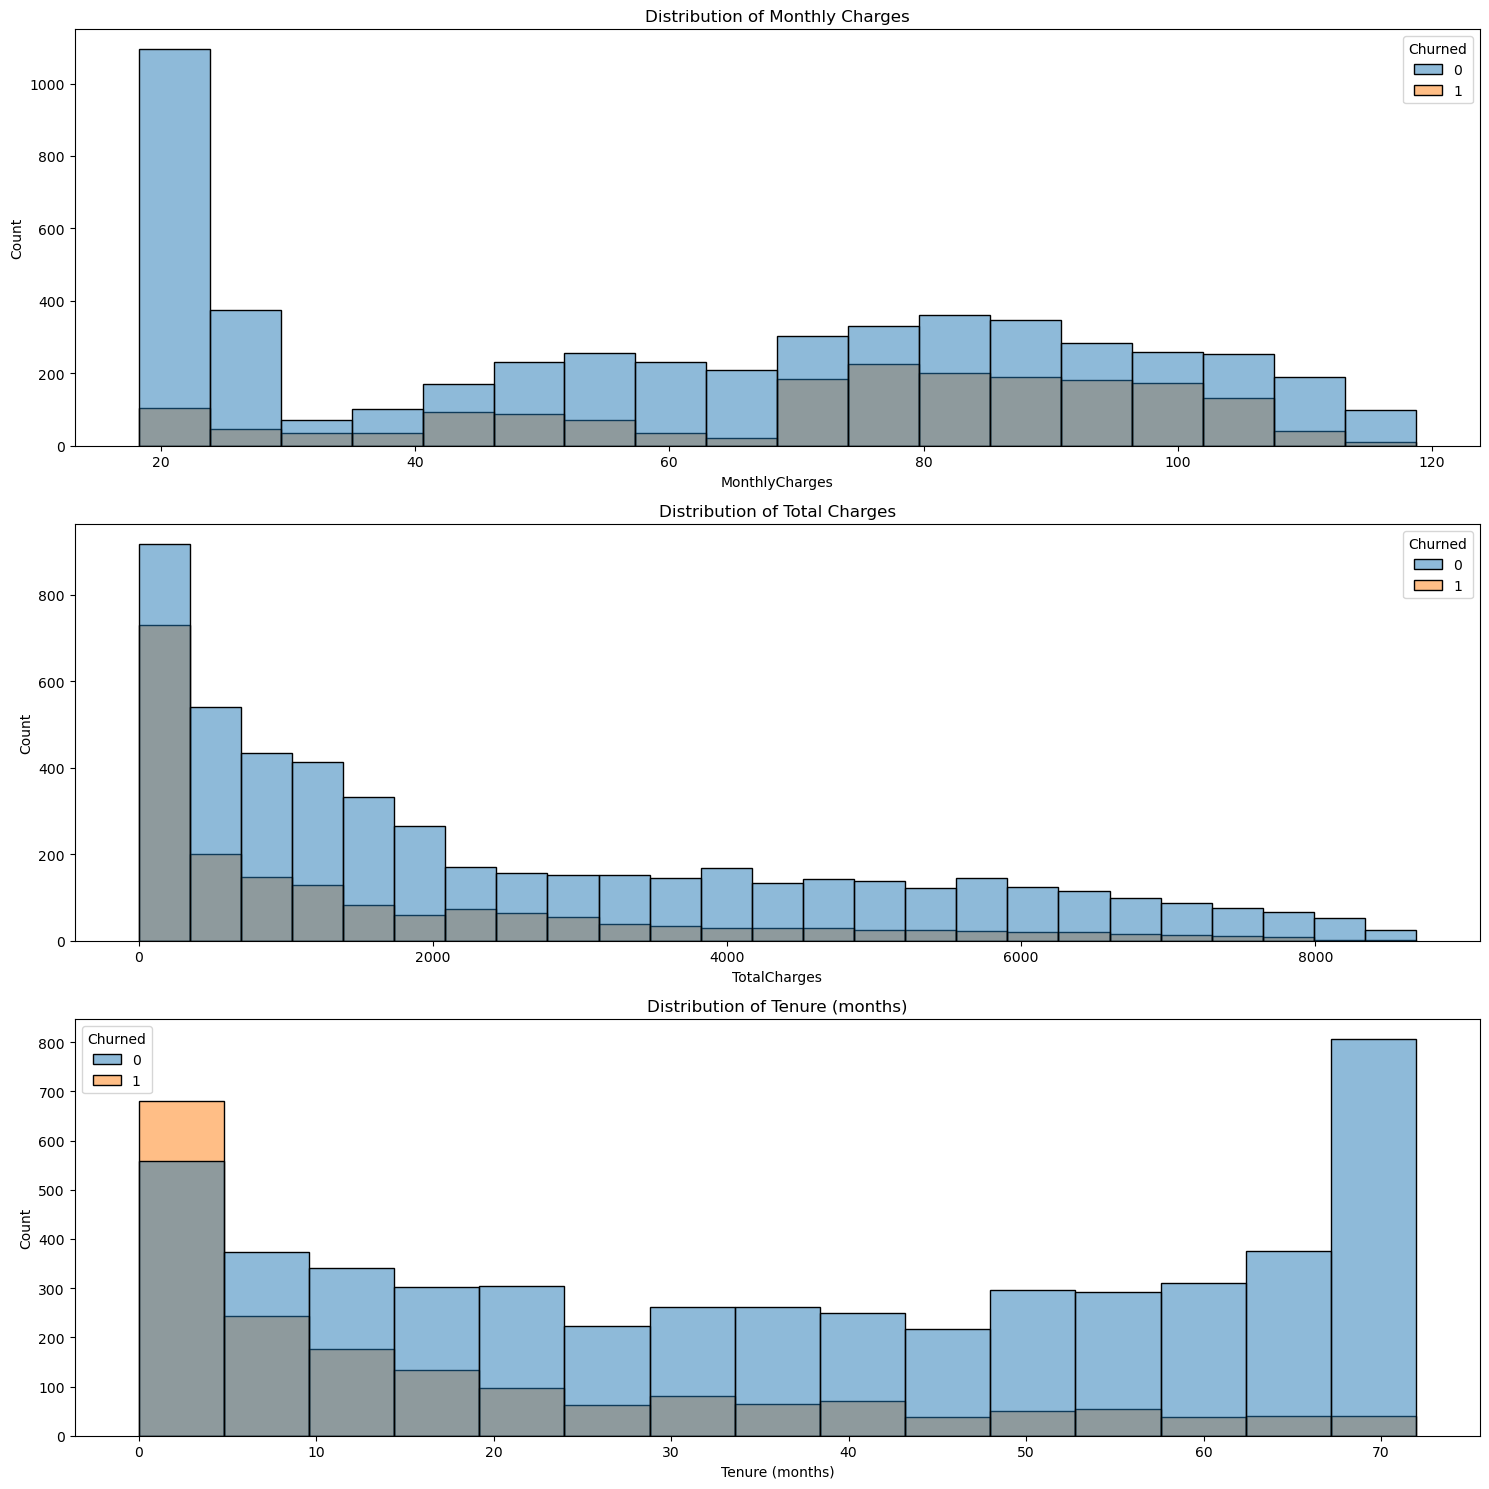

In [17]:
# Histogram for 'MonthlyCharges' with 'Churned' overlay
fig, axes = plt.subplots(3, 1, figsize=[15,15])
sns.histplot(data=df_final,
             x='MonthlyCharges',
             hue='Churned',
             ax=axes[0])
axes[0].set_title('Distribution of Monthly Charges')
sns.histplot(data=df_final,
             x='TotalCharges',
             hue='Churned',
             ax=axes[1])
axes[1].set_title('Distribution of Total Charges')
sns.histplot(data=df_final,
             x='Tenure (months)',
             hue='Churned',
             ax=axes[2])
axes[2].set_title('Distribution of Tenure (months)')
plt.tight_layout()
plt.show()


In [18]:
# Analyzing the Churn rate for categorical features
# Step A: get all object-dtype columns
categorical_cols = df_final.select_dtypes(include='object').columns

#Step B: drop columns with no meaningful information
categorical_cols = categorical_cols.drop(['customerID', 'EndDate'])

#Step C: Loop over remaining names, calling churn rate function on each
for col in categorical_cols:
    result = churn_rate_by_category(df_final, col)
    print(f"---{col}---")
    print(result)

---Type---
                 sum  count  churn_rate
Type                                   
Month-to-month  1655   3875      0.4271
One year         166   1473      0.1127
Two year          48   1695      0.0283
---PaperlessBilling---
                   sum  count  churn_rate
PaperlessBilling                         
No                 469   2872      0.1633
Yes               1400   4171      0.3357
---PaymentMethod---
                            sum  count  churn_rate
PaymentMethod                                     
Bank transfer (automatic)   258   1544      0.1671
Credit card (automatic)     232   1522      0.1524
Electronic check           1071   2365      0.4529
Mailed check                308   1612      0.1911
---gender---
        sum  count  churn_rate
gender                        
Female  939   3488      0.2692
Male    930   3555      0.2616
---Partner---
          sum  count  churn_rate
Partner                         
No       1200   3641      0.3296
Yes       669   3402  

### Contract Type Summary Conclusion

- Roughly a 15x difference in Churn Rate between 'Month-to-Month' & 'Two year' contracts
- 'Month-to-Month' contracts allow clients to leave at the end of any given month, where 'Two year' contracts lock a client into tougher process to leave in the middle of the contract.

### Senior Citizen Sumary

- A Senior Citizen is roughly 1.8x more likely to leave then a non-Senior Citizen

### Internet Service Summary
- Fiber Optic clients are over 5x as likely to churn than those without Interconnect's internet services.
- This is counter-intuitive since Fiber Optics is typically a premium service
- Begs the question: Is it a quality problem? Is it a pricing problem? Is it something else entirely?

### Multiple Lines Summary
- The spread here is less than 5 points
- This doesn't seem to have that large of an impact on the churn rate

### Payment Method Summary
- Electronic Check payment method is almost 3x higher than the other 3 payment methdods
- Begs the question: Is there a correlation between any of the other features with this payment method?

# Phase 3 - Target & Feature Engineering

In [19]:
# Derive 'HasInternet' column to show clients who have Internet Services
df_final['HasInternet'] = (df_final['InternetService'] != 'No Service').astype(int)

#print(df_final.head(20))
df_final['HasInternet'].value_counts()

HasInternet
1    5517
0    1526
Name: count, dtype: int64

In [20]:
# List of 6 columns linked ot 'HasInternet'
internet_services = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

# Loop over 6 columns and replace 'No Service' with 'No'
for i in internet_services:
    df_final[i] = df_final[i].replace('No Service', 'No')
    

In [21]:
# Derive 'HasPhone' column to show clients who have Phone Services
df_final['HasPhone'] = (df_final['MultipleLines'] != 'No Service').astype(int)

# Clean 'MultipleLines' column to only have 'Yes' or 'No' values
df_final['MultipleLines'] = df_final['MultipleLines'].replace('No Service', 'No')

df_final['MultipleLines'].value_counts()

MultipleLines
No     4072
Yes    2971
Name: count, dtype: int64

In [22]:
# Using pd.get_dummies for 'PaymentMethod' feature
payment_dummies = pd.get_dummies(df_final['PaymentMethod'], prefix='PaymentMethod', drop_first=True)
payment_dummies = payment_dummies.astype(int)

df_final = pd.concat([df_final, payment_dummies], axis=1).drop(columns=['PaymentMethod'])

#print(df_final.head(10))

In [23]:
# Filtering out 'No Service' from 'InternetService' column for dummies creation
df_final['InternetService'] = df_final['InternetService'].replace('No Service', np.nan)

# Using pd.get_dummies for 'InternetService' feature
internet_dummies = pd.get_dummies(df_final['InternetService'], prefix='InternetService', drop_first=True, dummy_na=False)
internet_dummies = internet_dummies.astype(int)

df_final = pd.concat([df_final, internet_dummies], axis=1).drop(columns=['InternetService'])

#print(df_final.head(10))
#df_final.info()


In [24]:
# filter to verify that all dummies have been created and no 'No Service' values remain
df_final_filtered = df_final[df_final['HasInternet'] == 0]

#print(len(df_final))
#print(df_final_filtered.head(20))

In [25]:
# Using Ordinal Encoding for 'Type' feature
type_mapping = {'Month-to-month': 0, 'One year': 1, 'Two year': 2}
df_final['Type'] = df_final['Type'].map(type_mapping)

#df_final['Type'].value_counts()

In [26]:
# Using Ordinal Encoding for 'gender' feature
gender_mapping = {'Female': 0, 'Male': 1}
df_final['gender'] = df_final['gender'].map(gender_mapping)


In [27]:
# Looping through the categorical columns to create a binary mapping dictionary for each column
cat_col_list = ['PaperlessBilling', 'Partner', 'Dependents', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'MultipleLines']
cat_col_mapping = {'Yes': 1, 'No': 0}

for col in cat_col_list:
    df_final[col] = df_final[col].map(cat_col_mapping)


In [28]:
#df_final.info()

In [29]:
# Building the features and target variable for the model
X = df_final.drop(columns=['customerID', 'BeginDate', 'EndDate', 'EndDate_dt', 'Churned'])
y = df_final['Churned']

In [30]:
# Splitting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RND, stratify=y)

y_train.value_counts(normalize=True)

Churned
0    0.734647
1    0.265353
Name: proportion, dtype: float64

In [31]:

y_test.value_counts(normalize=True)

Churned
0    0.734564
1    0.265436
Name: proportion, dtype: float64

In [32]:
print(X_train.shape)
print(X_test.shape)


(5634, 22)
(1409, 22)


# Phase 4 - Model Training

In [33]:
results = []

### Logistic Regression

In [34]:
# Scale the features using StandardScaler
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [35]:
# Baseline Model - Logistic Regression with class_weight='balanced' to handle class imbalance
training_start_time = time.time()
model_0 = LogisticRegression(class_weight='balanced', random_state=RND)
model_0.fit(X_train_scaled,y_train)
model_0_time = round(time.time() - training_start_time, 4)


pred_start_time = time.time()
y_pred_0 = model_0.predict(X_test_scaled)
y_proba_0 = model_0.predict_proba(X_test_scaled)[:, 1]
model_0_pred_time = round(time.time() - pred_start_time, 4)

# Evaluate the model performance using accuracy and ROC AUC score
auc_0 = round(roc_auc_score(y_test, y_proba_0), 4)
acc_0 = round(accuracy_score(y_test, y_pred_0), 4)

results.append({'Model': 'Logistic Regression', 'AUC': auc_0, 'Accuracy': acc_0, 'Training Time': model_0_time, 'Prediction Time': model_0_pred_time})

print(f"Model 0 - AUC: {auc_0}, Accuracy: {acc_0}, Training Time: {model_0_time}, Prediction Time: {model_0_pred_time}")

Model 0 - AUC: 0.8417, Accuracy: 0.7388, Training Time: 0.0662, Prediction Time: 0.0003


### LightGBM

In [36]:
# LightGBM Model with is_unbalance=True to handle class imbalance
training_start_time = time.time()
model_1 = lgb.LGBMClassifier(is_unbalance=True, random_state=RND)
model_1.fit(X_train, y_train)
model_1_time = round(time.time() - training_start_time, 4)

pred_start_time = time.time()
y_pred_1 = model_1.predict(X_test)
y_proba_1 = model_1.predict_proba(X_test)[:, 1]
model_1_pred_time = round(time.time() - pred_start_time, 4)

# Evaluate the model performance using accuracy and ROC AUC score
auc_1 = round(roc_auc_score(y_test, y_proba_1), 4)
acc_1 = round(accuracy_score(y_test, y_pred_1), 4)

results.append({'Model': 'LightGBM', 'AUC': auc_1, 'Accuracy': acc_1, 'Training Time': model_1_time, 'Prediction Time': model_1_pred_time})

print(f"Model 1 - AUC: {auc_1}, Accuracy: {acc_1}, Training Time: {model_1_time}, Prediction Time: {model_1_pred_time}")

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1495, number of negative: 4139
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000544 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 692
[LightGBM] [Info] Number of data points in the train set: 5634, number of used features: 22
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.265353 -> initscore=-1.018328
[LightGBM] [Info] Start training from score -1.018328
Model 1 - AUC: 0.9049, Accuracy: 0.8318, Training Time: 0.2865, Prediction Time: 0.0081


### CatBoost

In [37]:
# CatBoost
training_start_time = time.time()
model_2 = CatBoostClassifier(auto_class_weights='Balanced', random_state=RND, verbose=False)
model_2.fit(X_train, y_train)
model_2_time = round(time.time() - training_start_time, 4)

pred_start_time = time.time()
y_pred_2 = model_2.predict(X_test)
y_proba_2 = model_2.predict_proba(X_test)[:, 1]
model_2_pred_time = round(time.time() - pred_start_time, 4)

# Evaluate the model performance using accuracy and ROC AUC score
auc_2 = round(roc_auc_score(y_test, y_proba_2), 4)
acc_2 = round(accuracy_score(y_test, y_pred_2), 4)

results.append({'Model': 'CatBoost', 'AUC': auc_2, 'Accuracy': acc_2, 'Training Time': model_2_time, 'Prediction Time': model_2_pred_time})

print(f"Model 2 - AUC: {auc_2}, Accuracy: {acc_2}, Training Time: {model_2_time}, Prediction Time: {model_2_pred_time}")

Model 2 - AUC: 0.8986, Accuracy: 0.8155, Training Time: 2.0885, Prediction Time: 0.0033


# Phase 5 - Evaluation

In [38]:
results_df = pd.DataFrame(results)

print(results_df)

                 Model     AUC  Accuracy  Training Time  Prediction Time
0  Logistic Regression  0.8417    0.7388         0.0662           0.0003
1             LightGBM  0.9049    0.8318         0.2865           0.0081
2             CatBoost  0.8986    0.8155         2.0885           0.0033


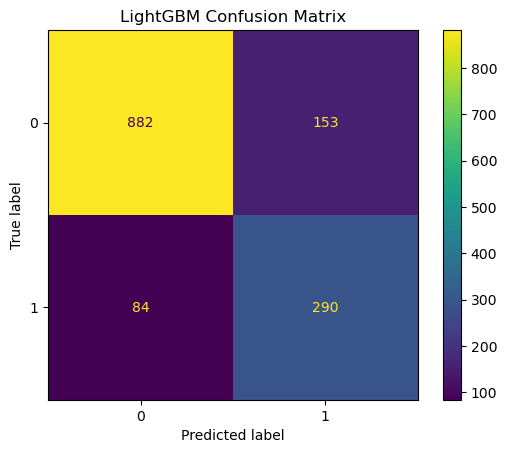

In [39]:
# Confusion Matrix for the best performing model (LightGBM)
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_1)
plt.title('LightGBM Confusion Matrix')
plt.show()

#### Confusion Matrix Interpretation

- Top-Left corner shows 882 customers who stayed and model correctly predicted to stay. (True Negatives)
- Top-Righ corner shows 153 customers who stayed, but model predicted they would churn (False Positives)
- Bottom-Left shows 84 customers who actually churned, but the model predicted they would stay. (False Negatives)
- Bottom-Right shows 290 customers who churned and the model correctly predicted they would churn.(True Positives)

Based on this data, Interconnect could potentially miss 84 customers who are about to churn and leave the company without Interconnect reaching out to offer them a "Promo code" or some other kind of savings. However, the company could also spend money reaching out to the 153 customers the model indicates are going to churn who actually had no thoughts of leaving the company. So this begs the question "Which side would cost the company more money...Not reaching out the the 84 before they leave or reaching out to the 153 because we think they might leave?

The **Recall** of the churned class is `290 / 374 = 77.54%`
The **Precision** of the churned class is `290 / 443 = 65.46%`

**Note**
Recall is the number of True Positives divided by the Total number of Customer's Churned
Precision is the number of True Positives divided by the Total number the Model Flagged as likely to Churn

#### Final Model Selection & SP Threshold

The best-performing model was **LightGBM**, achieving an AUC-ROC of **0.9049** and Accuracy of **83.18%** on the test set. 

Per the project's evaluation criteria, an AUC-ROC ≥ 0.88 corresponds to the maximum score tier of **6 SP**.


In [42]:
# Feature Importance for the best performing model (LightGBM)
feature_importance = pd.DataFrame({'Feature': X.columns, 'Importance': model_1.feature_importances_})
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

feature_importance

,Feature,Importance
15,Tenure (months),1155
2,MonthlyCharges,582
3,TotalCharges,468
0,Type,84
4,gender,75
19,PaymentMethod_Electronic check,66
8,OnlineSecurity,60
6,Partner,49
11,TechSupport,48
1,PaperlessBilling,47


#### Feature Importance — Interpretation Notes

The LightGBM feature importance ranking shows `Tenure (months)` as the dominant feature by a wide margin, followed by `MonthlyCharges` and `TotalCharges`. However, this ranking needs to be read alongside the EDA findings rather than taken at face value on its own.

**`Type` ranks lower than expected.** During EDA, `Type` (contract length) showed the strongest churn-rate spread of any feature — 42.7% Month-to-month vs 2.8% Two-year. Despite this, it ranks well below `Tenure (months)` in feature importance. This is likely explained by the relationship contract-type and tenure share together. For example: a Month-to-month customer has the opportunity to end a contract at the end of every month with very little issue; however, a Two-year customer typically has to deal with paying to get out of their contract and thus this tends to cause those customers to stick around longer. Because LightGBM found `tenure` to be the more flexible, finer-grained feature for capturing this signal, it likely "absorbed" much of the predictive value that would otherwise be attributed to `Type`. This is a known consequence of mulitcollinearity or feature overlap that was flagged earlier in EDA — it affects how credit is distributed across correlated features without necessarily hurting the model's overall predictive accuracy.

**`gender` ranks higher than expected.** EDA showed 26.92% vs 26.16% churn rate, indicating essentially no real relationship between gender and churn. Its appearance mid-table in feature importance does not contradict this — feature importance measures how often/usefully a feature was used across tree splits, not how strongly it correlates with the target on its own. With this being said, it is important to remember that a feature can pick up minor importance from noise or interaction effects even when it has no true meaningful standalone signal. For this reason, the EDA churn-rate comparison remains the more reliable and interpretable source for business conclusions about `gender`'s relevance.

**Takeaway:** feature importance from a tree ensemble is most useful for confirming overall predictive power, but EDA-level churn-rate analysis remains the clearer tool for identifying which individual business factors most directly drive churn — especially when features are correlated with one another.

## Conclusion

### Project Summary
This project set out to predict customer churn for Interconnect, a telecom operator, using contract, personal, internet, and phone service data for `7043` customers. The target was derived from the `EndDate` column, with churn defined as any customer whose contract had an end date on record. Given a class imbalance of roughly `73.5%/26.5%` retained-to-churned, AUC-ROC was used as the primary evaluation metric, with Accuracy as a secondary measure.

### Data Preparation
Four datasets were merged on `customerID`. Key preparation steps included:
- Cleaning `TotalCharges` (originally stored as an object dtype due to blank strings for new customers with zero elapsed billing periods)
- Deriving `tenure` from `BeginDate` and `EndDate`, using the data's snapshot date (February 1, 2020) as the reference point for still-active customers
- Collapsing redundant "No Service" categories across six internet add-on columns and `MultipleLines` into dedicated `HasInternet`/`HasPhone` flags, to avoid the same fact being duplicated across multiple encoded columns
- Encoding categorical features using strategy matched to each feature's structure: ordinal encoding for `Type` (given its inherent order), one-hot/dummy encoding for low-cardinality unordered categories, and manual binary mapping for two-category features

### Exploratory Findings
EDA identified `Type`, `InternetService`, `PaymentMethod`, `SeniorCitizen` as the strongest individual churn signals, with churn rates ranging from `2.83%` to `42.71%` depending on contract type alone. `gender` and `MultipleLines` showed negligible predictive value on their own. Cross-tabulation also revealed meaningful overlap between `Type` and `PaymentMethod` — [Month-to-month customers disproportionately paid via Electronic check] — suggesting these features may partially capture the same underlying "disengaged customer" pattern rather than acting as fully independent signals.

### Model Comparison

| Model | AUC-ROC | Accuracy | Training Time (s) | Prediction Time (s) |
|---|---|---|---|---|
| Logistic Regression | 0.8417 | 0.7388 | 0.0424 | 0.0003 |
| LightGBM | 0.9049 | 0.8318 | 0.1582 | 0.0067 |
| CatBoost | 0.8986 | 0.8155 | 2.0109 | 0.0038 |

**LightGBM was selected as the final model**, achieving the highest AUC-ROC `(0.9049)` — clearing the project's ≥0.88 threshold for the maximum score tier `(6 SP)` — while also training `12x` faster than CatBoost, which achieved comparable but slightly lower quality `(0.8986 AUC)` at a significantly higher training cost. Logistic regression, while fastest, produced the weakest separation between classes.

### Feature Importance vs. EDA
The `Tenure (months)` feature dominated teh importance ranking likely absorbing the signal that found during EDA that was attridbuted to `Type` due to their structural overlap. The higher ranekd importance of `gender` (compared to near zero during EDA) illsutrates that tree-based feature importance reflects split usage rather than standalone predicitve strengths.

### Business Recommendation
The final model's confusion matrix showed `84` missed churners (false negatives) against `153` customers incorrectly flagged as at-risk (false positives). Given that a missed churner represents a fully lost customer while a false positive only costs a modest promotional incentive, My recommendation is the Interconnect Marketing team should favor a model or decision threshold that prioritizes recall over precision for the churned class — the cost of a missed at-risk customer outweighs the cost of an unnecessary retention offer.